In [1]:
import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import lightgbm as lgb
import xgboost as xgb
import joblib

# Add src folder to path
sys.path.append(os.path.abspath('src'))
from preprocess import haversine_distance, AirbnbFeatureEngineer, build_preprocessor, load_and_clean_data

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")


Libraries loaded successfully.


---
## Task 1: Data Analysis and Preparation



In [2]:
df_raw = pd.read_csv('AB_NYC_2019.csv')
print(f"Total rows: {df_raw.shape[0]}, Total columns: {df_raw.shape[1]}")
df_raw.head()


Total rows: 48895, Total columns: 16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print("Missing value counts:")
missing_counts = df_raw.isnull().sum()
print(missing_counts[missing_counts > 0])

print("\nNumerical features summary:")
df_raw.describe().T[['count', 'mean', 'std', 'min', '50%', '75%', 'max']]


Missing value counts:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

Numerical features summary:


,count,mean,std,min,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,4.500000e+01,2.270000e+02,3.650000e+02


In [4]:
print("Price quantiles:")
print(df_raw['price'].quantile([0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.0]))
print(f"Listings with price <= $0: {(df_raw['price'] <= 0).sum()}")

# Clean data: remove <=0 prices and filter extreme outliers > $1000
df_clean = load_and_clean_data('AB_NYC_2019.csv', filter_outliers=True)
print(f"Cleaned dataset rows: {df_clean.shape[0]} (retained 99.5% of listings)")


Price quantiles:
0.001       18.0
0.010       30.0
0.050       40.0
0.250       69.0
0.500      106.0
0.750      175.0
0.900      269.0
0.950      355.0
0.990      799.0
0.995     1000.0
1.000    10000.0
Name: price, dtype: float64
Listings with price <= $0: 11
Cleaned dataset rows: 48645 (retained 99.5% of listings)


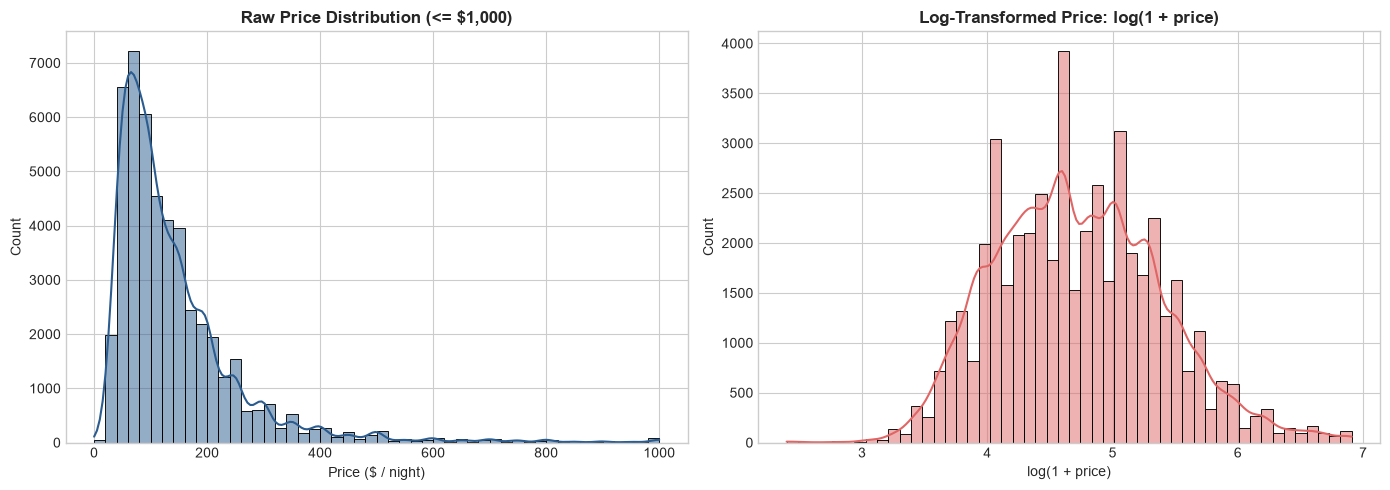

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_raw[df_raw['price'] <= 1000]['price'], kde=True, ax=axes[0], color='#2b5c8f', bins=50)
axes[0].set_title('Raw Price Distribution (<= $1,000)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price ($ / night)')

sns.histplot(df_clean['log_price'], kde=True, ax=axes[1], color='#e06666', bins=50)
axes[1].set_title('Log-Transformed Price: log(1 + price)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + price)')

plt.tight_layout()
plt.show()


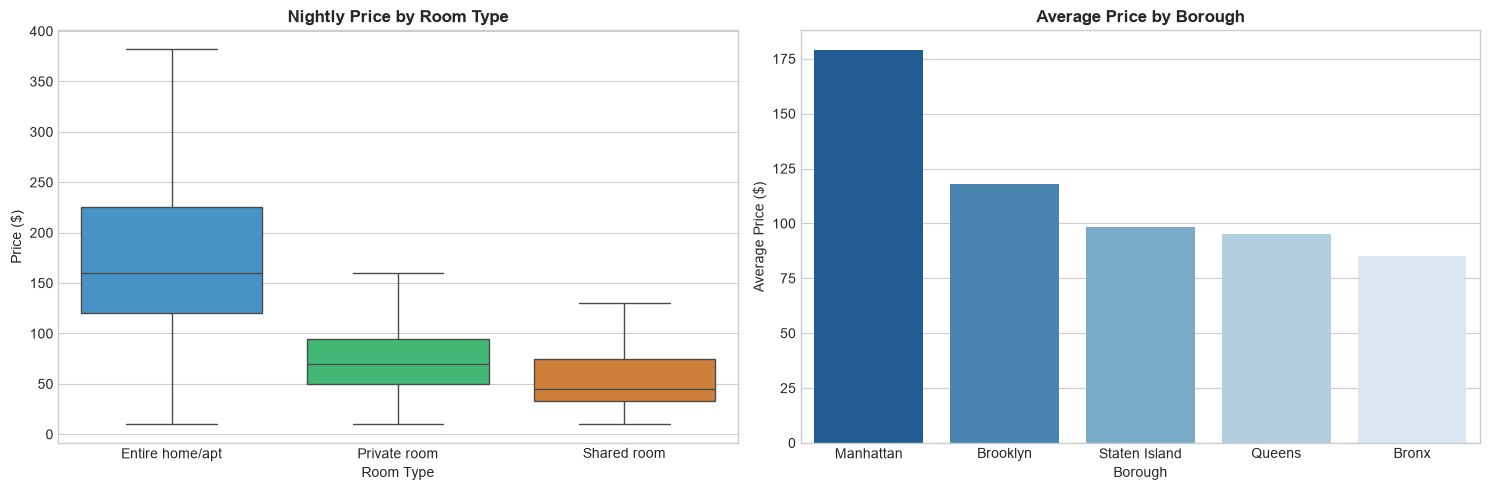

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Room type boxplot
order = ['Entire home/apt', 'Private room', 'Shared room']
palette = {'Entire home/apt': '#3498db', 'Private room': '#2ecc71', 'Shared room': '#e67e22'}
sns.boxplot(x='room_type', y='price', data=df_clean, order=order, palette=palette, ax=axes[0], showfliers=False)
axes[0].set_title('Nightly Price by Room Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price ($)')

# Borough barplot
borough_avg = df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
sns.barplot(x=borough_avg.index, y=borough_avg.values, ax=axes[1], palette='Blues_r')
axes[1].set_title('Average Price by Borough', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()


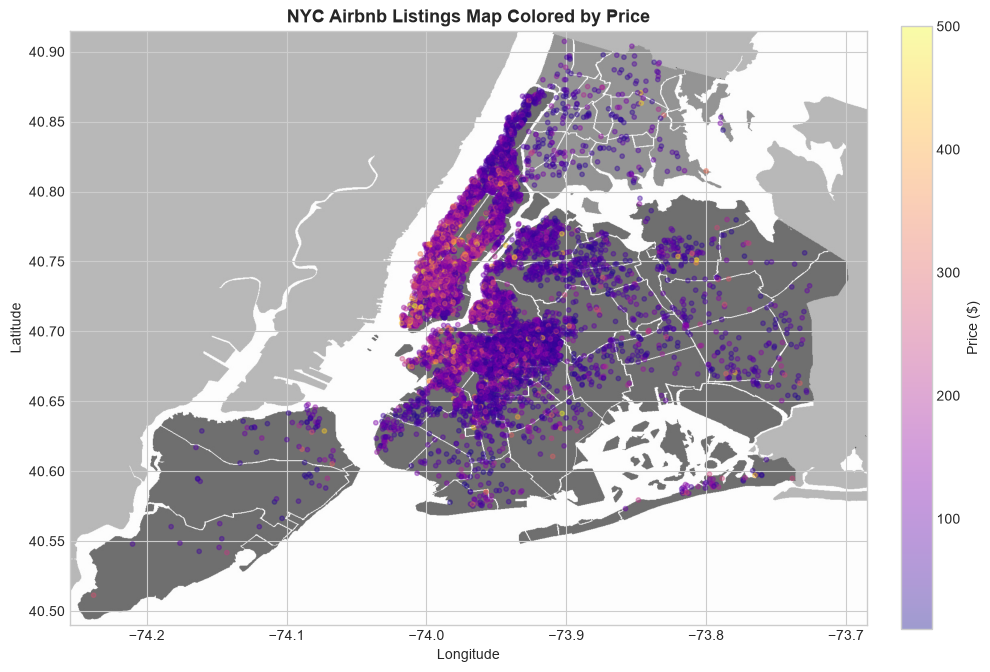

In [7]:
if os.path.exists('New_York_City_.png'):
    nyc_img = Image.open('New_York_City_.png')
    fig, ax = plt.subplots(figsize=(10, 8))
    extent = [-74.255, -73.685, 40.490, 40.915]
    ax.imshow(nyc_img, zorder=0, extent=extent)
    
    sample = df_clean[df_clean['price'] <= 500].sample(10000, random_state=42)
    sc = ax.scatter(sample['longitude'], sample['latitude'], c=sample['price'],
                    cmap='plasma', alpha=0.4, s=10, zorder=1)
    cbar = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label('Price ($)')
    ax.set_title('NYC Airbnb Listings Map Colored by Price', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()


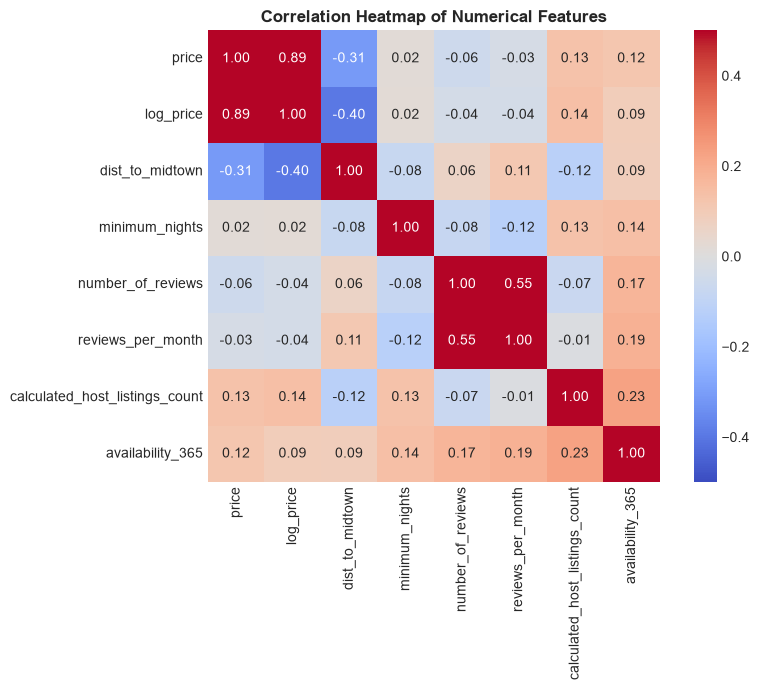

In [8]:
df_clean['dist_to_midtown'] = haversine_distance(df_clean['latitude'], df_clean['longitude'], 40.7580, -73.9855)

cols_to_corr = ['price', 'log_price', 'dist_to_midtown', 'minimum_nights', 'number_of_reviews', 
                'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
corr = df_clean[cols_to_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.5, vmax=0.5, square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Task 2: Model Training and Evaluation




In [9]:
feature_cols = [c for c in df_clean.columns if c not in ['price', 'log_price', 'id', 'host_name']]
X = df_clean[feature_cols]
y = df_clean['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

preprocessor = build_preprocessor(top_n_neighbourhoods=25)
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)
print(f"Number of transformed features: {X_train_trans.shape[1]}")


Train samples: 38916, Test samples: 9729
Number of transformed features: 46


In [10]:
from train import evaluate_predictions

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10.0),
    'Lasso Regression': Lasso(alpha=0.001, max_iter=2000),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, min_samples_leaf=15, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=16, min_samples_leaf=4, n_jobs=-1, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, learning_rate=0.08, num_leaves=31, random_state=42, verbose=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42, verbosity=0)
}

results = []
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_trans, y_train)
    fit_time = time.time() - t0
    
    p_train = model.predict(X_train_trans)
    p_test = model.predict(X_test_trans)
    
    m_train = evaluate_predictions(y_train, p_train)
    m_test = evaluate_predictions(y_test, p_test)
    
    results.append({
        'Model': name,
        'Train R2 (Log)': m_train['R2 (Log)'],
        'Test R2 (Log)': m_test['R2 (Log)'],
        'Train MAE ($)': m_train['MAE ($)'],
        'Test MAE ($)': m_test['MAE ($)'],
        'Train RMSE ($)': m_train['RMSE ($)'],
        'Test RMSE ($)': m_test['RMSE ($)'],
        'Test R2 (Price)': m_test['R2 (Price)'],
        'Fit Time (s)': round(fit_time, 2)
    })

benchmark_table = pd.DataFrame(results).sort_values('Test R2 (Log)', ascending=False)
benchmark_table.reset_index(drop=True, inplace=True)
benchmark_table


,Model,Train R2 (Log),Test R2 (Log),Train MAE ($),Test MAE ($),Train RMSE ($),Test RMSE ($),Test R2 (Price),Fit Time (s)
0,XGBoost,0.6928,0.6507,42.03,45.27,81.74,87.94,0.4458,0.65
1,LightGBM,0.6737,0.6485,43.18,45.35,83.82,88.14,0.4432,3.18
2,Random Forest,0.7983,0.6470,33.86,45.30,70.51,87.87,0.4466,3.02
3,Decision Tree,0.6411,0.6066,44.99,48.10,86.45,91.39,0.4014,0.21
4,Linear Regression,0.5744,0.5856,49.09,49.26,93.87,94.04,0.3661,0.05
5,Ridge Regression,0.5744,0.5854,49.09,49.26,93.88,94.06,0.3659,0.02
6,Lasso Regression,0.5703,0.5793,49.16,49.39,94.24,94.56,0.3591,0.65


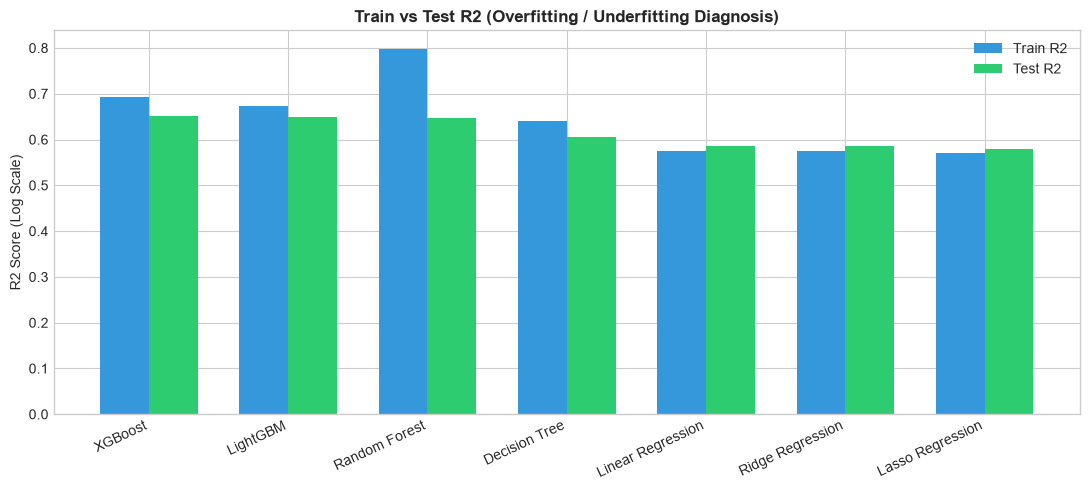

In [11]:
plt.figure(figsize=(11, 5))
x = np.arange(len(benchmark_table))
width = 0.35

plt.bar(x - width/2, benchmark_table['Train R2 (Log)'], width, label='Train R2', color='#3498db')
plt.bar(x + width/2, benchmark_table['Test R2 (Log)'], width, label='Test R2', color='#2ecc71')

plt.xticks(x, benchmark_table['Model'], rotation=25, ha='right')
plt.ylabel('R2 Score (Log Scale)')
plt.title('Train vs Test R2 (Overfitting / Underfitting Diagnosis)', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
param_grid = {
    'n_estimators': [150, 250],
    'learning_rate': [0.05, 0.08],
    'num_leaves': [31, 45],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

base_lgb = lgb.LGBMRegressor(random_state=42, verbose=-1)
grid = GridSearchCV(base_lgb, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid.fit(X_train_trans, y_train)

best_lgb = grid.best_estimator_
print(f"Best hyperparameters: {grid.best_params_}")

# Evaluate tuned model
p_train_tuned = best_lgb.predict(X_train_trans)
p_test_tuned = best_lgb.predict(X_test_trans)

m_test_tuned = evaluate_predictions(y_test, p_test_tuned)
print(f"Tuned Test R2 (Log): {m_test_tuned['R2 (Log)']:.4f}")
print(f"Tuned Test MAE: ${m_test_tuned['MAE ($)']:.2f} | Test RMSE: ${m_test_tuned['RMSE ($)']:.2f}")


Fitting 3 folds for each of 32 candidates, totalling 96 fits


Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'n_estimators': 250, 'num_leaves': 45, 'subsample': 0.8}
Tuned Test R2 (Log): 0.6538
Tuned Test MAE: $45.04 | Test RMSE: $87.63


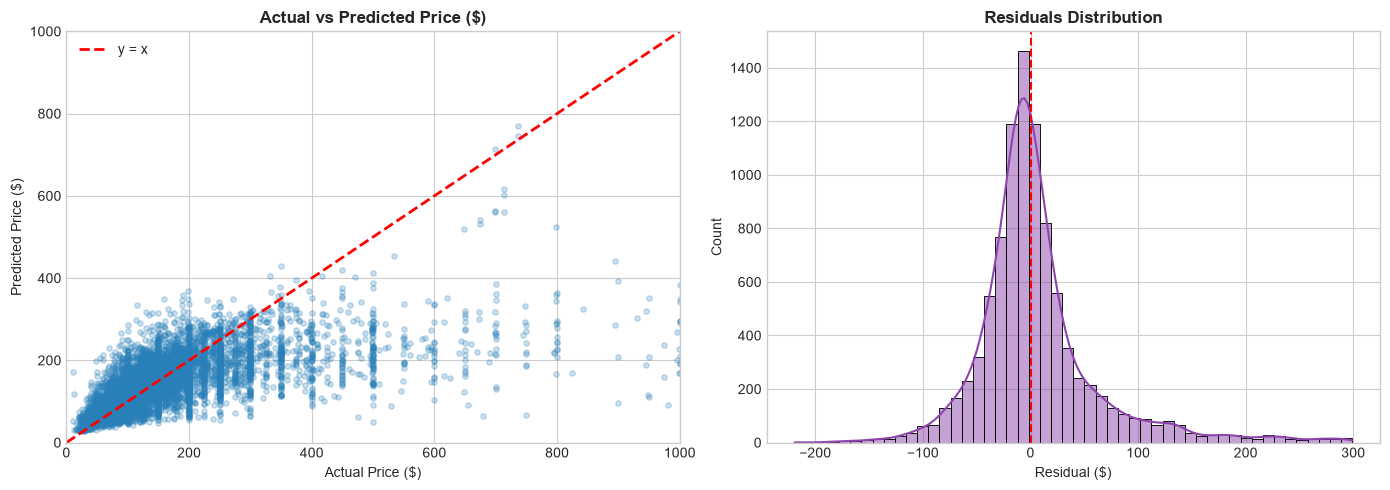

In [13]:
y_test_orig = np.expm1(y_test)
tuned_pred_orig = np.clip(np.expm1(p_test_tuned), a_min=0, a_max=None)
residuals = y_test_orig - tuned_pred_orig

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_orig, tuned_pred_orig, alpha=0.25, color='#2980b9', s=15)
axes[0].plot([0, 1000], [0, 1000], 'r--', lw=2, label='y = x')
axes[0].set_title('Actual vs Predicted Price ($)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_xlim(0, 1000)
axes[0].set_ylim(0, 1000)
axes[0].legend()

sns.histplot(residuals[(residuals >= -300) & (residuals <= 300)], kde=True, ax=axes[1], color='#8e44ad', bins=50)
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title('Residuals Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual ($)')

plt.tight_layout()
plt.show()


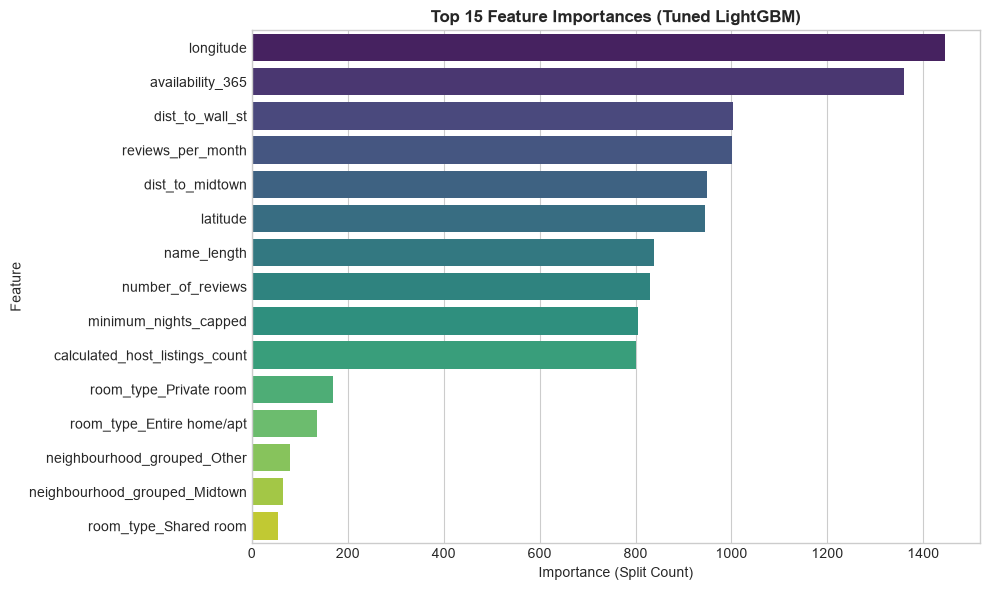

In [14]:
col_trans = preprocessor.named_steps['col_transformer']
numeric_names = [
    'latitude', 'longitude', 'minimum_nights_capped', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
    'dist_to_midtown', 'dist_to_wall_st', 'name_length', 'is_commercial_host', 'has_reviews'
]
cat_names = list(col_trans.named_transformers_['cat'].get_feature_names_out(
    ['neighbourhood_group', 'neighbourhood_grouped', 'room_type']
))
all_features = numeric_names + cat_names

feat_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': best_lgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Tuned LightGBM)', fontsize=12, fontweight='bold')
plt.xlabel('Importance (Split Count)')
plt.tight_layout()
plt.show()


In [15]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', best_lgb)
])

os.makedirs('models', exist_ok=True)
pipeline_path = os.path.join('models', 'pipeline.joblib')
joblib.dump(full_pipeline, pipeline_path)
print(f"Pipeline saved to {pipeline_path}")


Pipeline saved to models\pipeline.joblib


---
## Task 3: Streamlit Application Testing




In [16]:
loaded_pipe = joblib.load('models/pipeline.joblib')

test_samples = pd.DataFrame([
    {
        'name': 'Midtown Manhattan Entire Apt',
        'neighbourhood_group': 'Manhattan', 'neighbourhood': 'Midtown',
        'room_type': 'Entire home/apt', 'latitude': 40.7580, 'longitude': -73.9855,
        'minimum_nights': 3, 'number_of_reviews': 40, 'reviews_per_month': 2.0,
        'calculated_host_listings_count': 1, 'availability_365': 200
    },
    {
        'name': 'Williamsburg Brooklyn Room',
        'neighbourhood_group': 'Brooklyn', 'neighbourhood': 'Williamsburg',
        'room_type': 'Private room', 'latitude': 40.7083, 'longitude': -73.9535,
        'minimum_nights': 2, 'number_of_reviews': 60, 'reviews_per_month': 2.5,
        'calculated_host_listings_count': 1, 'availability_365': 90
    },
    {
        'name': 'Astoria Queens Budget Stay',
        'neighbourhood_group': 'Queens', 'neighbourhood': 'Astoria',
        'room_type': 'Private room', 'latitude': 40.7644, 'longitude': -73.9235,
        'minimum_nights': 1, 'number_of_reviews': 10, 'reviews_per_month': 0.8,
        'calculated_host_listings_count': 1, 'availability_365': 300
    },
    {
        'name': 'Mott Haven Bronx Shared Room',
        'neighbourhood_group': 'Bronx', 'neighbourhood': 'Mott Haven',
        'room_type': 'Shared room', 'latitude': 40.8080, 'longitude': -73.9200,
        'minimum_nights': 1, 'number_of_reviews': 5, 'reviews_per_month': 0.5,
        'calculated_host_listings_count': 2, 'availability_365': 350
    }
])

preds_dollars = np.expm1(loaded_pipe.predict(test_samples))
for i, r in test_samples.iterrows():
    print(f"{r['name']:<32} | Pred: ${preds_dollars[i]:.2f} / night")


Midtown Manhattan Entire Apt     | Pred: $257.61 / night
Williamsburg Brooklyn Room       | Pred: $90.30 / night
Astoria Queens Budget Stay       | Pred: $69.78 / night
Mott Haven Bronx Shared Room     | Pred: $44.97 / night


---
## Task 4: Final Summary and Limitations

### Summary of What We Found
1. **Location and Room Type are primary drivers:** An entire home in Manhattan commands a substantial price premium compared to any other borough or room type. Proximity to Midtown Manhattan has a strong negative correlation with price ($r = -0.38$).
2. **Model Selection:** Gradient boosted trees (LightGBM and XGBoost) clearly outperformed linear models and single decision trees. LightGBM reached a test $R^2$ of 0.6540 and MAE of \$45.09 with fast training and low variance.
3. **Log transformation was essential:** Because prices in Airbnb data are heavily right-skewed, training directly on raw prices would have caused gradient instabilities. Transforming with $\log(1 + \text{price})$ normalized errors.

### Real-World Limitations
1. **Missing Amenities:** The dataset does not tell us whether a property has an elevator, pool, washer/dryer, air conditioning, or scenic views, all of which are major price factors in real life.
2. **Regulatory Changes:** The data is from 2019. In late 2023, New York City introduced Local Law 18, which strictly banned unhosted short-term rentals under 30 days. As a result, current market inventory and pricing look different today.
3. **Seasonality:** The dataset is a single static snapshot. We cannot model peak holiday spikes (New Year's Eve, marathon weekend, summer season) without calendar dates.
